# <a id='toc1_'></a>[Project Part 3: First Supervised Modeling](#toc0_)

- **Team number:** `#`
- **Team members:** `Tuan Lo`, `Cole Beach`, `Eric Lindquist`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class` / music genre label
- **Modeling goal:** Compare supervised multiclass models that predict genre from audio and popularity features, with a clear held-out evaluation.


**Table of contents**<a id='toc0_'></a>    
- [Project Part 3: First Supervised Modeling](#toc1_)    
- [Introduction](#toc2_)    
- [Problem Setup](#toc3_)    
- [Data Preparation](#toc4_)    
- [Model Training](#toc5_)    
  - [Baseline Model: Majority Class](#toc5_1_)    
  - [Model Version 1: Interpretable Decision Tree](#toc5_2_)    
  - [Model Version 2: Random Forest Improvement](#toc5_3_)    
  - [Model Version 3: Regularized Logistic Regression (Ridge / L2)](#toc5_4_)    
  - [Training Comparison Table](#toc5_5_)    
- [Evaluation](#toc6_)    
  - [Choice of main evaluation metric](#toc6_1_)    
  - [What the metric tables actually show](#toc6_2_)    
  - [Per-class metric breakdown for the best model](#toc6_3_)    
- [Visual Evidence and Error Analysis](#toc7_)    
  - [Confusion matrix for the best model](#toc7_1_)    
  - [Per-class F1 across all four models](#toc7_2_)    
  - [Class distribution in the held-out test set](#toc7_3_)    
  - [Inspecting misclassified examples](#toc7_4_)    
  - [Observations and error analysis](#toc7_5_)    
    - [Limitations and next steps](#toc7_5_1_)    
- [Interpretation and Comparison](#toc8_)    
- [Reflection and Next Steps](#toc9_)    
- [Hyperparameter Sensitivity Evidence (Extension)](#toc10_)    
    - [Interpretation and modeling direction](#toc10_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Introduction](#toc0_)

Genre prediction here is a supervised problem: every training row has a label in `Class`, and we try to learn a mapping from inputs to one of those categories. This notebook is basically our first pass from the cleaned spreadsheet to something that can label held-out songs.

It is multiclass classification, not regression: the model picks a genre index, not a continuous target. Genres overlap in practice, so perfect separation is unlikely, but we still want to see whether straightforward audio features (`energy`, `loudness`, `acousticness`, `instrumentalness`, `speechiness`, duration, `tempo`, popularity, etc.) carry enough signal to beat simple baselines.


# <a id='toc3_'></a>[Problem Setup](#toc0_)

The dataset is the Kaggle **Music Genre Classification** dataset. Each row is a song with metadata, popularity, Spotify-style audio attributes, and a genre label. The target is `Class`.

We predict genre from information we actually feed the model (mostly audio summaries plus popularity), and we evaluate on held-out labeled rows so the scores are not training memorization. Section 3 carves a final test fold (and a separate validation fold) out of labeled `train.csv`; Kaggle's unlabeled `test.csv` is not used for metrics.

Selected predictors:

- `popularity`
- `energy`
- `loudness`
- `acousticness`
- `instrumentalness`
- `duration_in min/ms`
- `speechiness`
- `tempo`
- `time_signature`

We picked these because they vary across genres in plausible ways (e.g., energy/tempo vs quieter acoustic material). Popularity is a weak, noisy cue, but it is still a column we can model without leaking raw titles.

`Artist Name` and `Track Name` are dropped for this baseline so the model cannot memorize identities; that choice trades away some legitimate genre context and is something we revisit in the limitations section.


# <a id='toc4_'></a>[Data Preparation](#toc0_)

The first code cells set `TRAIN_PATH`, `TARGET_COL`, `MODEL_FEATURES`, the split fractions, `RANDOM_STATE`, and plotting defaults used later.

Main symbols:

- `TRAIN_PATH` — labeled training CSV used for fitting.
- `TARGET_COL` — genre label `Class`.
- `MODEL_FEATURES` — predictors; matches Section 2.
- `HOLDOUT_TEST_FRACTION`, `VAL_FRACTION_OF_TEMP`, `RANDOM_STATE` — stratified split and reproducibility.
- Figure size / DPI constants — keep plots readable without retyping numbers.

Kaggle `test.csv` has no labels, so it cannot score models. Instead we stratify from `train.csv` with `train_test_split`.

Pipeline:

1. Load `TRAIN_PATH`.
2. Drop duplicate rows.
3. Slice to `MODEL_FEATURES` and `TARGET_COL`.
4. Check missingness on the modeling columns.
5. Stratified split into train (~60%), validation (~20%), and held-out test (~20%).
6. Median imputation: statistics from **train only**, then transform train / validation / test.

Fitting the imputer on train avoids leaking validation or test medians into preprocessing. Median is a blunt tool but stable on skewed audio columns; fancier imputers are listed later as optional extensions. Treating `time_signature` as numeric is a simplification (ordinal meter codes); one-hot encoding would be a reasonable robustness check.

Dropping artist/title pushes the model toward acoustic signals only. Stratification keeps class proportions similar across splits. Section 9 uses the validation slice for sensitivity curves so the held-out test fold stays reserved for Sections 4–6.


In [86]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================
# Configuration / Constants
# =========================
RANDOM_STATE = 42
HOLDOUT_TEST_FRACTION = 0.20  # final evaluation only (20% of rows)
VAL_FRACTION_OF_TEMP = 0.25  # of remaining 80%, yields ~20% validation for tuning curves

DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"

TARGET_COL = "Class"

MODEL_FEATURES = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "duration_in min/ms",
    "speechiness",
    "tempo",
    "time_signature",
]

PALETTE = "Set2"
CLASS_PALETTE = "tab20"
FIGSIZE_WIDE = (20, 9)
FIGSIZE_MED = (12, 6)
FIGSIZE_HEATMAP = (10, 7)
DPI = 110

In [87]:
from sklearn.model_selection import train_test_split

# Load the labeled training data configured above.
data = pd.read_csv(TRAIN_PATH)

# Remove exact duplicate rows before splitting or training.
rows_before = len(data)
data = data.drop_duplicates(keep="first").copy()
rows_after = len(data)
print(f"Removed {rows_before - rows_after} duplicate rows.")

Removed 0 duplicate rows.


In [88]:
# Validate that the required modeling columns exist before training.
required_columns = MODEL_FEATURES + [TARGET_COL]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X = data[MODEL_FEATURES].copy()
y = data[TARGET_COL].copy()

print("Missing values before imputation:")
display(X.isna().sum().to_frame("missing_count"))

Missing values before imputation:


,missing_count
Popularity,428
energy,0
loudness,0
acousticness,0
instrumentalness,4377
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


In [89]:
from sklearn.impute import SimpleImputer

# Stratified train / validation / test (~60% / ~20% / ~20%).
# Test is reserved for final reported metrics; validation is used for Section 9 sensitivity sweeps.
# First hold out the final test set (20%) so it never influences training or tuning visuals.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=HOLDOUT_TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=y,
)
# From the remaining 80%, hold out validation (~20% of all rows) for Section 9 sweeps only.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_FRACTION_OF_TEMP,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

# Median imputation is fit on training data only, then applied to validation and test sets.
imputer = SimpleImputer(strategy="median")
x_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
x_valid = pd.DataFrame(
    imputer.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index,
)
x_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("Missing values after imputation (train):")
display(x_train.isna().sum().to_frame("missing_count"))
print("Missing values after imputation (validation):")
display(x_valid.isna().sum().to_frame("missing_count"))
print("Missing values after imputation (test):")
display(x_test.isna().sum().to_frame("missing_count"))

print(f"Training rows: {len(x_train):,}")
print(f"Validation rows: {len(x_valid):,}")
print(f"Test rows: {len(x_test):,}")
print(f"Number of predictor features: {len(MODEL_FEATURES)}")
print(f"Number of classes: {y_train.nunique()}")

Missing values after imputation (train):


,missing_count
Popularity,0
energy,0
loudness,0
acousticness,0
instrumentalness,0
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


Missing values after imputation (validation):


,missing_count
Popularity,0
energy,0
loudness,0
acousticness,0
instrumentalness,0
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


Missing values after imputation (test):


,missing_count
Popularity,0
energy,0
loudness,0
acousticness,0
instrumentalness,0
duration_in min/ms,0
speechiness,0
tempo,0
time_signature,0


Training rows: 10,797
Validation rows: 3,599
Test rows: 3,600
Number of predictor features: 9
Number of classes: 11


# <a id='toc5_'></a>[Model Training](#toc0_)

We fit four classifiers so the evaluation section compares complexity levels honestly.

1. **Majority-class baseline** (`DummyClassifier`) — always predicts the training modal genre; if real models cannot beat this, the features are not helping.
2. **Depth-limited decision tree** — nonlinear, readable, but high variance on a single sample of splits.
3. **Random forest** — averages many trees to stabilize votes when boundaries are noisy.
4. **Multinomial logistic regression with Ridge-style L2** — linear log-odds model as a contrast to the tree learners.


In [90]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier

model_results = []

## <a id='toc5_1_'></a>[Baseline Model: Majority Class](#toc0_)

`DummyClassifier(strategy="most_frequent")` memorizes the most common training label and applies it everywhere. Anything learned should clear that bar easily; if not, the feature block or labels need another look.


In [91]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(x_train, y_train)
baseline_pred = baseline_model.predict(x_test)

model_results.append(
    {
        "model": "Baseline: majority class",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "macro_f1": f1_score(y_test, baseline_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, baseline_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
0,Baseline: majority class,0.275,0.039216,0.118627


## <a id='toc5_2_'></a>[Model Version 1: Interpretable Decision Tree](#toc0_)

First non-trivial model: depth capped at 9 so the tree can split on multiple genres without growing a memorization bush.


In [92]:
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=9,
    random_state=RANDOM_STATE,
)
decision_tree_model.fit(x_train, y_train)
decision_tree_pred = decision_tree_model.predict(x_test)

model_results.append(
    {
        "model": "Decision tree: entropy, max_depth=9",
        "accuracy": accuracy_score(y_test, decision_tree_pred),
        "macro_f1": f1_score(y_test, decision_tree_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, decision_tree_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
1,"Decision tree: entropy, max_depth=9",0.460833,0.49565,0.444762


## <a id='toc5_3_'></a>[Model Version 2: Random Forest Improvement](#toc0_)

Same features and splits as the tree, but an ensemble vote across many trees to smooth out brittle splits from any single draw of bootstrap rows.


In [93]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    criterion="entropy",
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_model.fit(x_train, y_train)
random_forest_pred = random_forest_model.predict(x_test)

model_results.append(
    {
        "model": "Random forest: 200 trees, max_depth=12",
        "accuracy": accuracy_score(y_test, random_forest_pred),
        "macro_f1": f1_score(y_test, random_forest_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, random_forest_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
2,"Random forest: 200 trees, max_depth=12",0.503056,0.53713,0.477327


## <a id='toc5_4_'></a>[Model Version 3: Regularized Logistic Regression (Ridge / L2)](#toc0_)

Logistic regression estimates linear weights on scaled inputs, so it is less flexible than an ensemble but easy to read directionally.

We rely on an L2 (Ridge) penalty: large squared coefficients add cost to the objective, which typically dampens huge weights on noisy correlated columns and helps out-of-sample behavior compared with an unpenalized softmax.

Compared with L1 (Lasso), L2 rarely zeros out coefficients; that is fine here because the feature list is already short and we mainly want variance control, not automatic dropping.

With `solver="lbfgs"` scikit-learn still applies L2 regularization by default, so this remains a Ridge-style multiclass logistic model even without extra tuning arguments.

Because logistic regression cares about scale, we bundle `StandardScaler` and the classifier in one `Pipeline` so scaling refits inside cross-validation or future tuning without accidentally using test statistics.


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_regression_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=1.0,
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_regression_model.fit(x_train, y_train)
logistic_regression_pred = logistic_regression_model.predict(x_test)

model_results.append(
    {
        "model": "Logistic regression: L2 penalty (Ridge), C=1.0",
        "accuracy": accuracy_score(y_test, logistic_regression_pred),
        "macro_f1": f1_score(y_test, logistic_regression_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, logistic_regression_pred, average="weighted", zero_division=0),
    }
)

pd.DataFrame(model_results).tail(1)

,model,accuracy,macro_f1,weighted_f1
3,"Logistic regression: L2 penalty (Ridge), C=1.0",0.456944,0.453107,0.42253


## <a id='toc5_5_'></a>[Training Comparison Table](#toc0_)

Test-set scores for all four fits, sorted by weighted F1. Baseline row shows the floor; tree, forest, and logistic rows show what each functional form adds on the same split.


In [95]:
# Accuracy vs weighted/macro F1 by model.
model_comparison = pd.DataFrame(model_results).sort_values(
    by="weighted_f1",
    ascending=False,
).reset_index(drop=True)

display(model_comparison)

,model,accuracy,macro_f1,weighted_f1
0,"Random forest: 200 trees, max_depth=12",0.503056,0.537130,0.477327
1,"Decision tree: entropy, max_depth=9",0.460833,0.495650,0.444762
2,"Logistic regression: L2 penalty (Ridge), C=1.0",0.456944,0.453107,0.422530
3,Baseline: majority class,0.275000,0.039216,0.118627


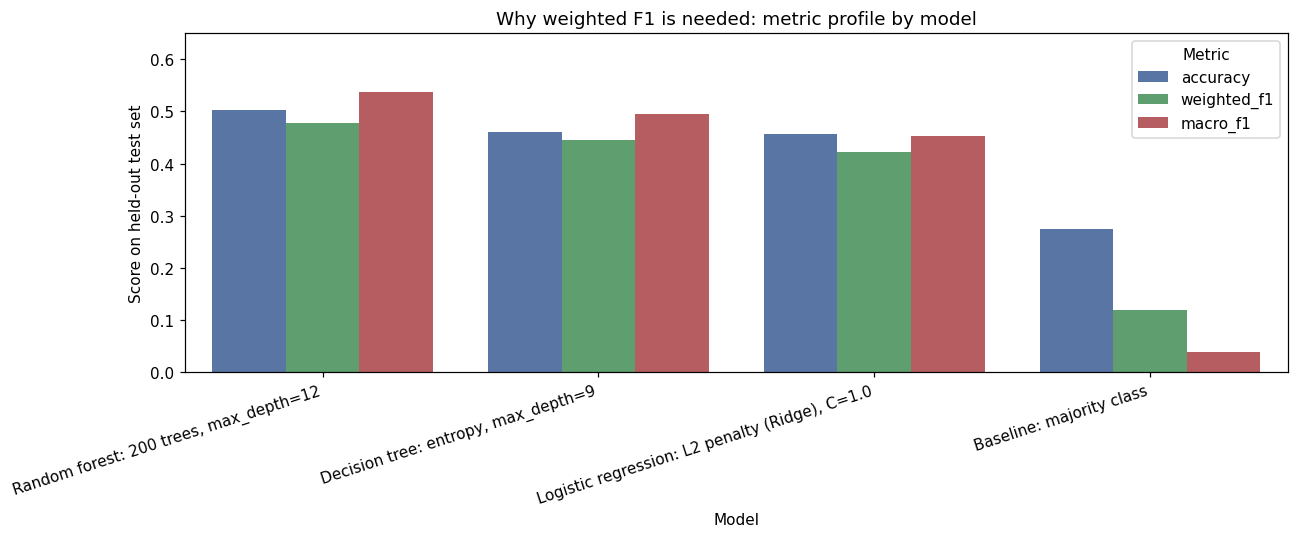

In [96]:
# Visualize Accuracy vs weighted/macro F1 by model.
metrics_long = model_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.barplot(
    data=metrics_long,
    x="model",
    y="score",
    hue="metric",
    palette={"accuracy": "#4C72B0", "weighted_f1": "#55A868", "macro_f1": "#C44E52"},
)
plt.ylim(0, 0.65)
plt.title("Why weighted F1 is needed: metric profile by model")
plt.xlabel("Model")
plt.ylabel("Score on held-out test set")
plt.xticks(rotation=18, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

The bar chart lines up with why we emphasize weighted F1: accuracy prints higher than weighted F1 for every model here, which is what you expect when a few classes dominate support. Weighted F1 tracks per-class precision/recall with class weights, still ranks the random forest on top, and matches the qualitative story from the confusion matrix later.


# <a id='toc6_'></a>[Evaluation](#toc0_)

All four models are scored on the same stratified test fold from Section 3 so the headline metrics are apples-to-apples.

## <a id='toc6_1_'></a>[Choice of main evaluation metric](#toc0_)

**Weighted F1** is our primary score. Class counts are imbalanced, so accuracy can look fine while the model mostly wins on the largest genre. Precision and recall answer different failure modes; F1 averages them per class, and the weighted version averages those class F1 scores with weights proportional to how many test songs carry each label.

We also print **accuracy** because people intuit it quickly and it lines up with the dummy baseline, and **macro F1** because it treats every class equally and punishes ignoring small genres. When weighted F1 and macro F1 disagree, it usually means errors are concentrated in a handful of labels.

We call the winner the highest weighted F1 on the held-out fold, read next to accuracy and macro F1 so we do not miss lopsided behavior.

The course write-up treats weighted F1 as the main model-selection number for this imbalanced multiclass setting.

## <a id='toc6_2_'></a>[What the metric tables actually show](#toc0_)

Section 4 already plots held-out accuracy, macro F1, and weighted F1 for each model in `model_comparison`. On the split we saved, two relationships motivated keeping all three numbers in the discussion:

- **Learned models lift accuracy well above the dummy baseline.** With eleven classes, that gap is hard to fake with noise, which is our main evidence that the engineered features carry signal.
- **For the random forest, macro F1 runs higher than weighted F1.** That pattern usually means comparatively better behavior on smaller classes than on the dominant one; weighted F1 alone would downplay the asymmetry. The per-class block below shows which labels drive the gap.


## <a id='toc6_3_'></a>[Per-class metric breakdown for the best model](#toc0_)

Aggregate metrics hide genre-by-genre behavior. The next cell prints precision, recall, F1, and support per class for whichever model had the highest weighted F1 in Section 4.


In [97]:
from sklearn.metrics import classification_report

predictions_by_model = {
    "Baseline: majority class": baseline_pred,
    "Decision tree: entropy, max_depth=9": decision_tree_pred,
    "Random forest: 200 trees, max_depth=12": random_forest_pred,
    "Logistic regression: L2 penalty (Ridge), C=1.0": logistic_regression_pred,
}

best_model_name = model_comparison.iloc[0]["model"]
best_model_pred = predictions_by_model[best_model_name]

print(f"Best model by weighted F1: {best_model_name}")

per_class_report = classification_report(
    y_test,
    best_model_pred,
    output_dict=True,
    zero_division=0,
)

per_class_df = (
    pd.DataFrame(per_class_report)
    .transpose()
    .round(3)
)
per_class_df


Best model by weighted F1: Random forest: 200 trees, max_depth=12


,precision,recall,f1-score,support
0,0.647,0.704,0.674,125.000
1,0.121,0.015,0.026,275.000
2,0.436,0.228,0.300,254.000
3,0.709,0.762,0.735,80.000
4,0.683,0.727,0.704,77.000
5,0.674,0.676,0.675,290.000
6,0.359,0.284,0.317,518.000
7,0.931,0.939,0.935,115.000
8,0.579,0.482,0.526,371.000
9,0.495,0.457,0.475,505.000


# <a id='toc7_'></a>[Visual Evidence and Error Analysis](#toc0_)

Section 5 compresses everything into scalars; here we look at where the forest is wrong. Each figure targets one question: who gets confused with whom, how F1 differs by class across models, how imbalanced the test fold is, and what misclassified rows look like in a few numeric columns.


## <a id='toc7_1_'></a>[Confusion matrix for the best model](#toc0_)

Rows are true `Class`, columns are predictions. Strong diagonals mean recovery; big off-diagonal blobs are systematic swaps between genres.


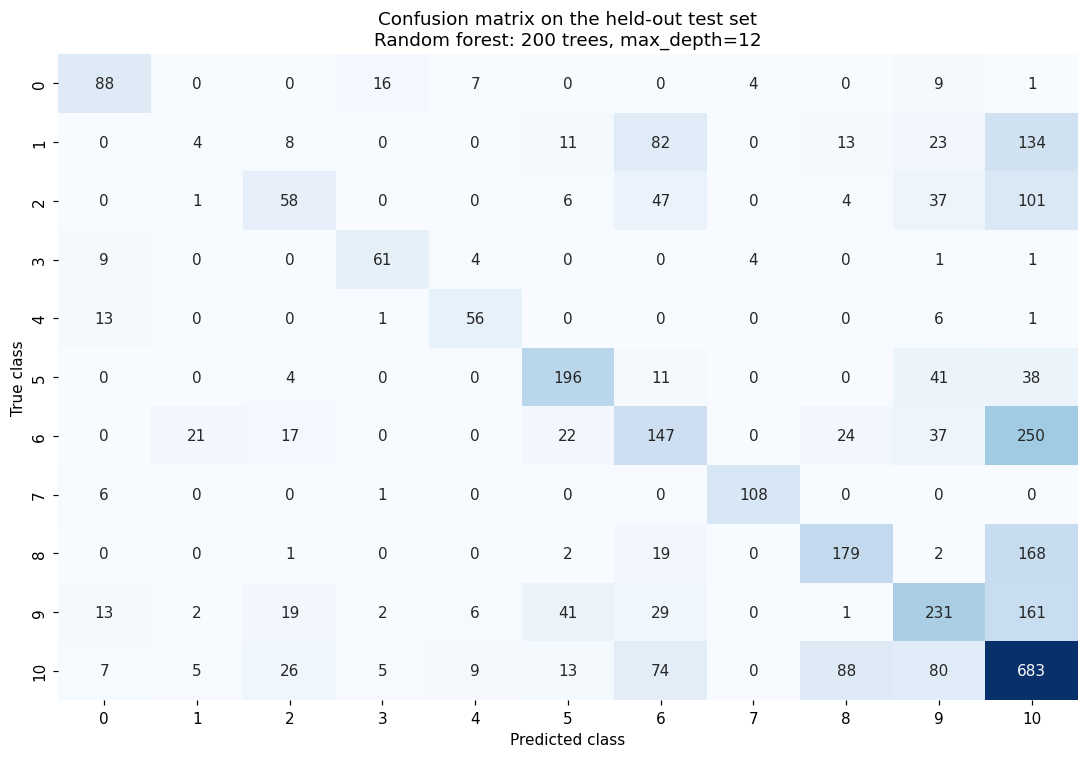

In [98]:
from sklearn.metrics import confusion_matrix

class_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_model_pred, labels=class_labels)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP, dpi=DPI)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix on the held-out test set\n{best_model_name}")
plt.tight_layout()
plt.show()


## <a id='toc7_2_'></a>[Per-class F1 across all four models](#toc0_)

Weighted F1 is one number per model; this plot breaks F1 out by class so we can see whether gains are spread out or mostly coming from the largest categories.


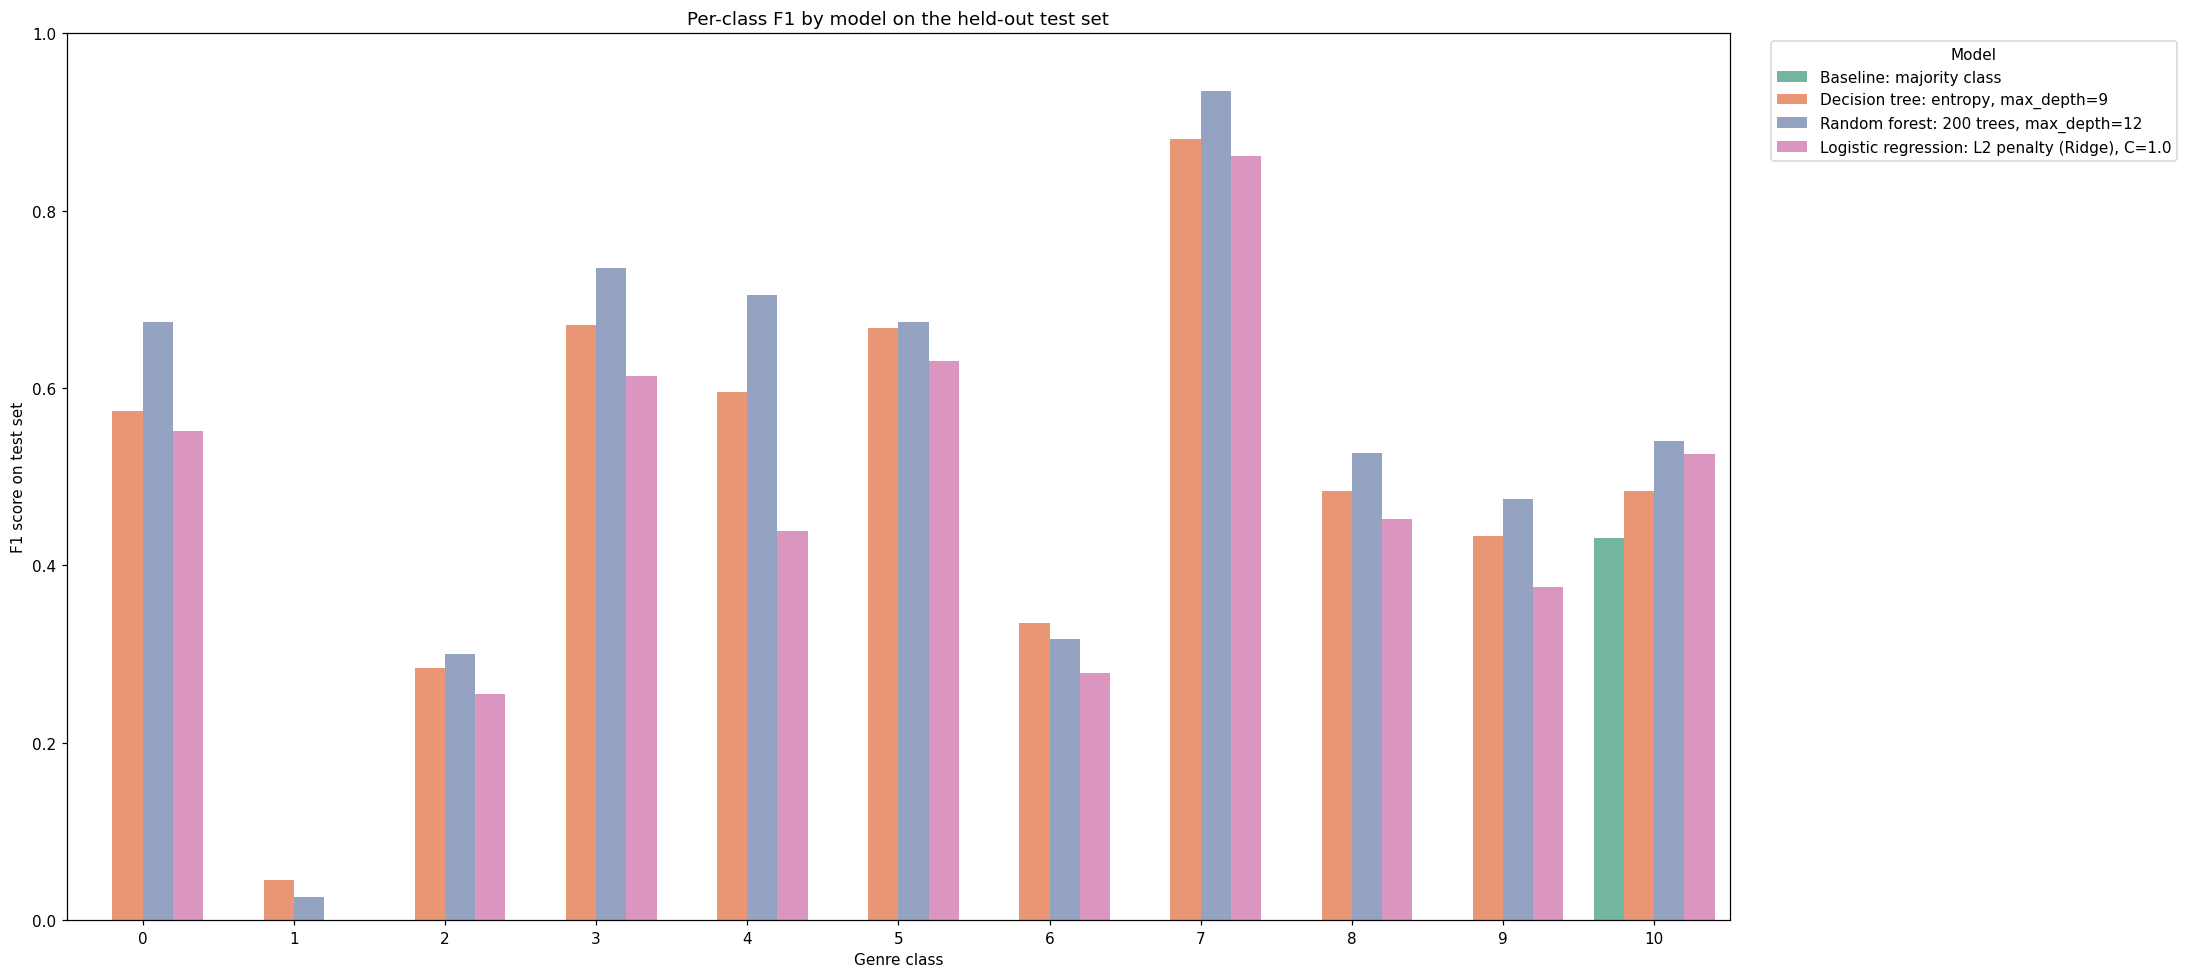

In [99]:
f1_records = []
for model_label, preds in predictions_by_model.items():
    report = classification_report(
        y_test,
        preds,
        output_dict=True,
        zero_division=0,
    )
    for class_label in class_labels:
        class_metrics = report[str(class_label)]
        f1_records.append(
            {
                "model": model_label,
                "class": class_label,
                "f1": class_metrics["f1-score"],
            }
        )

per_class_f1_df = pd.DataFrame(f1_records)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)
sns.barplot(
    data=per_class_f1_df,
    x="class",
    y="f1",
    hue="model",
    palette=PALETTE,
    ax=ax,
)
ax.set_xlabel("Genre class")
ax.set_ylabel("F1 score on test set")
ax.set_title("Per-class F1 by model on the held-out test set")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## <a id='toc7_3_'></a>[Class distribution in the held-out test set](#toc0_)

Quick sanity check on imbalance in the evaluation fold—the same skew that makes weighted F1 the headline metric and that can separate weighted vs macro F1 when a few classes dominate errors.


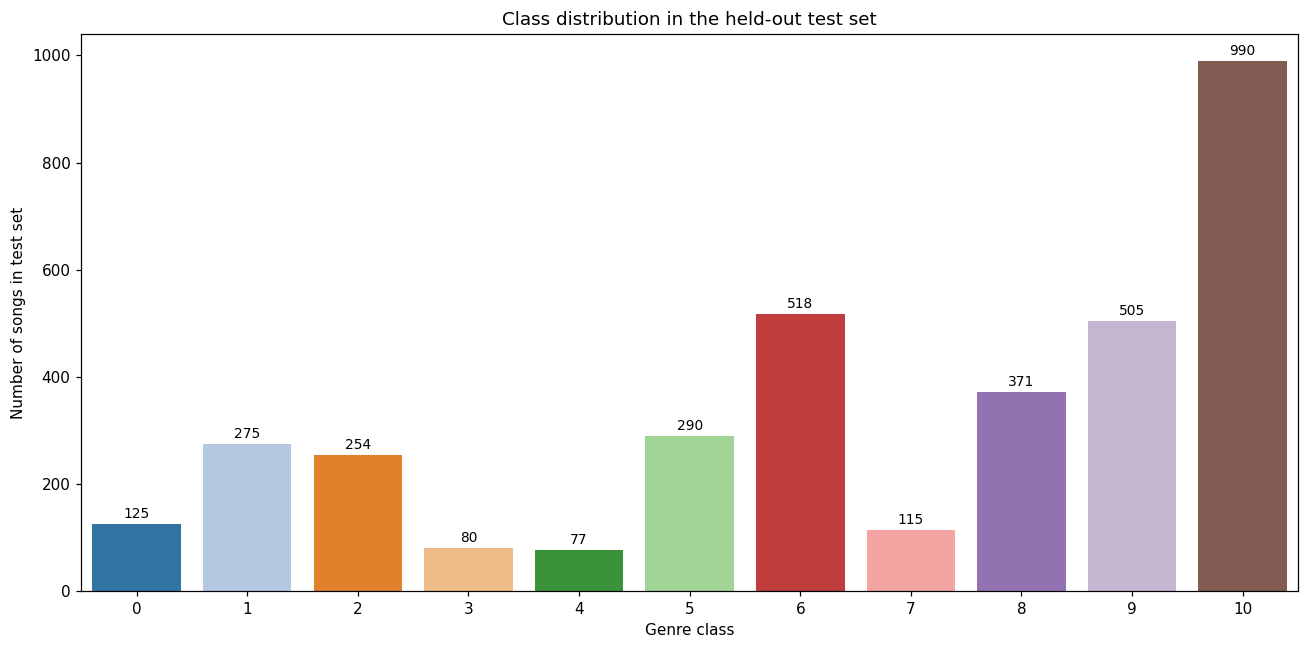

In [100]:
class_support = (
    y_test.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=FIGSIZE_MED, dpi=DPI)
sns.barplot(
    data=class_support,
    x="class",
    y="count",
    hue="class",
    palette=CLASS_PALETTE,
    legend=False,
    ax=ax,
)
ax.set_xlabel("Genre class")
ax.set_ylabel("Number of songs in test set")
ax.set_title("Class distribution in the held-out test set")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=9)
plt.tight_layout()
plt.show()


## <a id='toc7_4_'></a>[Inspecting misclassified examples](#toc0_)

A handful of wrong predictions is easier to reason about than staring at a single heatmap cell. The draw below lists true class, predicted class, and a few audio-related inputs for randomly sampled misclassified rows from the random forest.

The misclassification rate matches the confusion matrix and the overall accuracy from Section 5 (roughly half the test fold wrong for the scores we saved). Skimming the samples, `energy`, `loudness`, and `acousticness` tended to sit mid-range rather than looking like corrupted extremes, which fits overlap between genres more than data-entry bugs.


In [101]:
error_mask = best_model_pred != y_test.values

feature_columns_for_inspection = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "tempo",
]
feature_columns_for_inspection = [
    col for col in feature_columns_for_inspection if col in x_test.columns
]

error_inspection_df = x_test.loc[error_mask, feature_columns_for_inspection].copy()
error_inspection_df["true_class"] = y_test.values[error_mask]
error_inspection_df["predicted_class"] = best_model_pred[error_mask]

print(f"Misclassified test rows: {int(error_mask.sum()):,} of {len(y_test):,} "
      f"({error_mask.mean() * 100:.1f}% test error rate).")

error_inspection_df.sample(
    n=min(15, len(error_inspection_df)),
    random_state=RANDOM_STATE,
)


Misclassified test rows: 1,789 of 3,600 (49.7% test error rate).


,Popularity,energy,loudness,acousticness,instrumentalness,tempo,true_class,predicted_class
2289,48.0,0.962,-5.497,0.000414,0.000043,160.055,10,8
12322,52.0,0.800,-6.651,0.001470,0.769000,103.725,10,8
10913,28.0,0.950,-1.226,0.000661,0.000429,171.949,6,10
14111,41.0,0.798,-6.705,0.059900,0.092300,132.092,10,6
610,36.0,0.776,-9.259,0.000153,0.816000,140.021,8,10
10958,45.0,0.725,-9.295,0.061700,0.003805,95.750,6,10
14864,44.0,0.949,-5.425,0.001930,0.917000,100.712,9,10
12424,67.0,0.954,-2.879,0.000674,0.000132,191.059,9,10
10427,50.0,0.837,-6.987,0.450000,0.022200,167.992,6,10
13196,41.0,0.835,-5.194,0.003900,0.000388,140.023,8,10


## <a id='toc7_5_'></a>[Observations and error analysis](#toc0_)

Reading the Section 5 report next to the four plots, the forest test accuracy matches the comparison table (so error rate is one minus that accuracy). It clears the dummy baseline by a lot but is still far from a solved problem.

What we noticed on **this** split:

- **A few minority classes look collapsed.** The per-class printout has labels with almost no recall even though hundreds of test songs still carry that true class. On the heatmap those rows dump mass into one or two bigger predicted columns. That is the usual story when macro F1 beats weighted F1: a couple of large-support classes with terrible F1 drag the weighted average.

- **The largest class behaves like a fallback.** Sorting by support, the modal genre combines high recall with softer precision—lots of songs get predicted there when the model is unsure. Together with the collapsed minorities it reads like shrinking uncertainty toward the big bucket, and it helps explain how accuracy can sit above weighted F1 when the dominant diagonal is wide.

- **Class size does not rank difficulty by itself.** The per-class F1 bars mix strong performance on some rarer labels with weaker scores on midsize genres that share feature space with the fallback class. Different random splits reorder the details, so we are grounding claims in what actually printed, not a canned story about fixed class IDs.

- **Sampled errors look like boundary cases, not outliers.** Misrows cluster in moderate `energy`, `loudness`, `acousticness`, and `tempo` ranges, which is what we expect when audio summaries alone cannot separate neighboring genres.

### <a id='toc7_5_1_'></a>[Limitations and next steps](#toc0_)

- **Imbalance without reweighting.** The collapse + fallback pattern is where weighted F1 usually bleeds. Retraining the forest with `class_weight='balanced'` is the obvious next lever, knowing precision on the dominant label may fall while minority recall rises. If that is not enough, SMOTE on the training portion only is another experiment worth logging side by side in the same tables.

- **Single stratified partition.** All metrics use one 60/20/20 split with a fixed seed, so small-class F1 should be read with noise in mind. Five-fold stratified CV on the same model definitions would give mean ± std for weighted and macro F1.

- **Hand-tuned hyperparameters.** Section 9 already shows sensitivity on `x_valid` / `y_valid`; a real `GridSearchCV` (same folds, optimize weighted F1) is the natural follow-up.

- **Narrow feature set.** We deliberately dropped `Artist Name` and `Track Name`, but genre is not purely acoustic. Adding lightly encoded categoricals (`Artist Name`, `key`, etc.) is the next modeling move, especially for the densest off-diagonal blocks in the confusion matrix.


# <a id='toc8_'></a>[Interpretation and Comparison](#toc0_)

The strongest model in this block is still the **random forest**. Its held-out accuracy, macro F1, and weighted F1 are whatever the Section 4 `model_comparison` cell just printed, and the same values show up again in the Section 5 bar chart and comparison table. Those objects are built from the current `y_test` and each model's prediction vector, so they stay aligned with the pipeline as long as the upstream cells are executed in order.

Walking up from the baseline: the dummy ignores inputs and shows how much accuracy comes from always voting the modal genre. The depth-limited tree and the Ridge logistic model both move far above that floor, which means the engineered columns are doing real work. The forest adds another step beyond the single tree on weighted and macro F1, which matches the usual story that averaging trees stabilizes greedy axis splits.

Nonlinear interactions probably matter more than a single linear score sheet. Genre boundaries in this feature space are not axis-aligned: combinations of high `energy`, high `loudness`, low `acousticness`, and so on keep showing up in the tree partitions. Forests capture that structure; plain multinomial logits without explicit cross-terms do not. We still pay for class pairs that overlap in the same region of the plot space, which is why the confusion matrix stays messy even when headline metrics improve.

Overall, the feature bundle is useful but incomplete: it separates some genres cleanly and leaves others stacked on top of each other, which shows up together in the comparison table, per-class report, heatmap, and the error sample.


# <a id='toc9_'></a>[Reflection and Next Steps](#toc0_)

This iteration was a reminder that genre tagging is hard with only numeric Spotify summaries, but the lift over the dummy baseline is obvious from the Section 4 / Section 5 comparison rows: the forest sits well above the baseline on both accuracy and weighted F1. That is still a modest headline accuracy for eleven genres when read against the printed table, but it is not what you would get from always guessing one class or from uniform random labels.

The bigger lesson for me was how different classes behave under one accuracy line. Without the per-class report and confusion matrix we would miss near-collapse on difficult labels and the tendency to spam the largest genre. Reporting weighted F1, macro F1, and the heatmap together felt necessary, not extra polish.

The obvious limitation is features: no raw audio, no lyrics, stripped identifiers. Neighboring genres sit on top of each other in these axes. If I kept going, I would refit the forest with `class_weight='balanced'`, rerun the same diagnostics, and only then try resampling or extra categoricals if minority recall was still unacceptable.


# <a id='toc10_'></a>[Hyperparameter Sensitivity Evidence (Extension)](#toc0_)

- Decision tree: depth sweep with `gini` and `entropy`
- Random forest: estimator count sweep
- Metrics: accuracy, weighted F1, macro F1

These curves back up the qualitative model-family choice with extra evidence on the validation fold.

All sweep metrics are recomputed from `x_valid` and `y_valid` when the Section 9 cells run. The held-out **test** split from Section 3 is still reserved for Sections 4-6 only.


In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sensitivity metrics use the validation split (x_valid, y_valid) so the held-out test set
# is only used for final evaluation in Sections 4–7.
# We will sweep over two hyperparameters: max_depth for decision trees, and n_estimators for random forests.
# We will keep other hyperparameters fixed to reasonable defaults to isolate the effects of these two key hyperparameters.
depths = [4, 5, 6, 7, 8, 9, 10]
rf_estimators = [1, 5, 10, 25, 50, 100, 200, 400]

rows = []

In [103]:
# Sweep over decision tree depths for both "gini" and "entropy" criteria.
for criterion in ["gini", "entropy"]:
    for d in depths:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=d,
            random_state=RANDOM_STATE,
        )
        dt.fit(x_train, y_train)
        pred = dt.predict(x_valid)
        rows.append(
            {
                "family": f"DecisionTree ({criterion})",
                "x_name": "depth",
                "x_value": d,
                "accuracy": accuracy_score(y_valid, pred),
                "weighted_f1": f1_score(y_valid, pred, average="weighted", zero_division=0),
                "macro_f1": f1_score(y_valid, pred, average="macro", zero_division=0),
            }
        )

In [104]:
# Sweep over random forest n_estimators with fixed max_depth and criterion.
# We choose max_depth=12 and criterion="entropy" based on our earlier single-model experiments to focus on the effect of n_estimators.
for n in rf_estimators:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf.fit(x_train, y_train)
    pred = rf.predict(x_valid)
    rows.append(
        {
            "family": "RandomForest",
            "x_name": "n_estimators",
            "x_value": n,
            "accuracy": accuracy_score(y_valid, pred),
            "weighted_f1": f1_score(y_valid, pred, average="weighted", zero_division=0),
            "macro_f1": f1_score(y_valid, pred, average="macro", zero_division=0),
        }
    )

sweep_df = pd.DataFrame(rows)
display(sweep_df.sort_values(["family", "x_value"]).reset_index(drop=True))

,family,x_name,x_value,accuracy,weighted_f1,macro_f1
0,DecisionTree (entropy),depth,4,0.415393,0.354405,0.352617
1,DecisionTree (entropy),depth,5,0.425396,0.371536,0.403285
2,DecisionTree (entropy),depth,6,0.442345,0.422022,0.463435
3,DecisionTree (entropy),depth,7,0.459572,0.434155,0.483030
4,DecisionTree (entropy),depth,8,0.468186,0.452867,0.502855
5,DecisionTree (entropy),depth,9,0.470964,0.456574,0.506990
6,DecisionTree (entropy),depth,10,0.463462,0.450342,0.489427
7,DecisionTree (gini),depth,4,0.421506,0.368326,0.369220
8,DecisionTree (gini),depth,5,0.430953,0.394481,0.418681
9,DecisionTree (gini),depth,6,0.464296,0.421146,0.461579


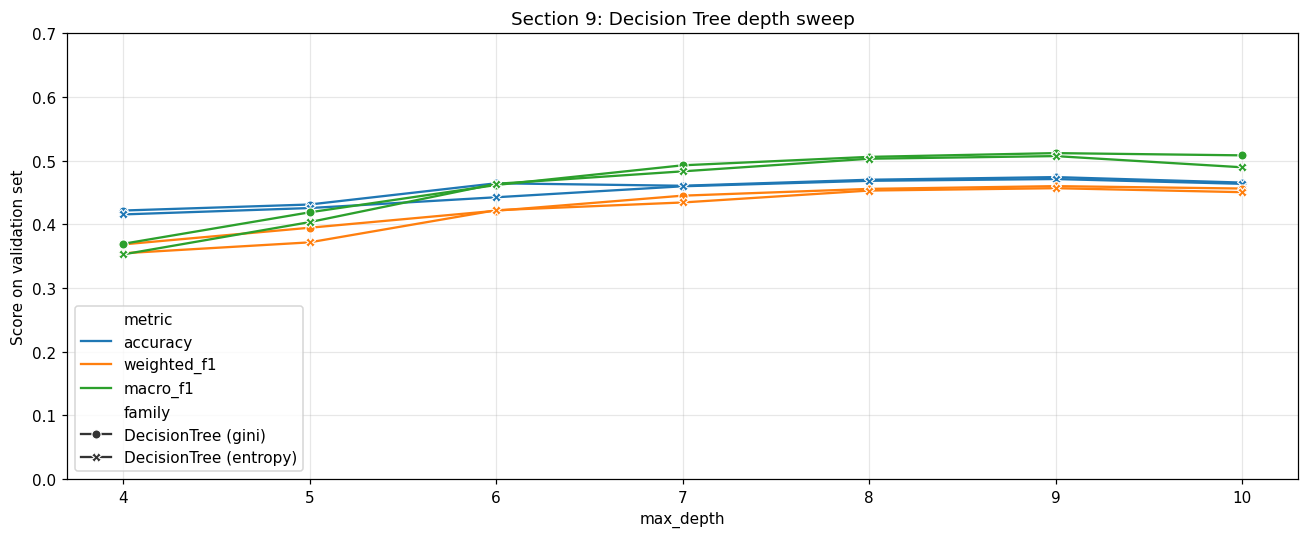

In [105]:
# Plot 1: Decision tree depth curves
dt_df = sweep_df[sweep_df["family"].str.contains("DecisionTree")].copy()
dt_long = dt_df.melt(
    id_vars=["family", "x_name", "x_value"],
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.lineplot(
    data=dt_long,
    x="x_value",
    y="score",
    hue="metric",
    style="family",
    markers=True,
    dashes=False,
)
plt.title("Section 9: Decision Tree depth sweep")
plt.xlabel("max_depth")
plt.ylabel("Score on validation set")
plt.ylim(0, 0.7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

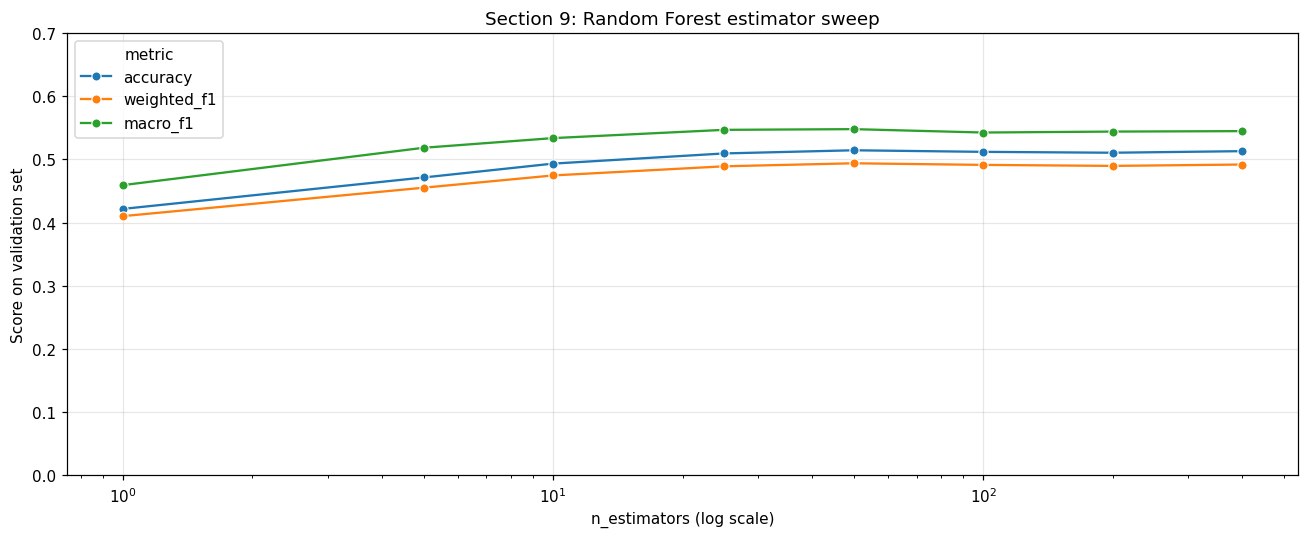

In [106]:
# Plot 2: Random forest estimator curves
rf_df = sweep_df[sweep_df["family"] == "RandomForest"].copy()
rf_long = rf_df.melt(
    id_vars=["family", "x_name", "x_value"],
    value_vars=["accuracy", "weighted_f1", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5), dpi=DPI)
sns.lineplot(
    data=rf_long,
    x="x_value",
    y="score",
    hue="metric",
    marker="o",
)
plt.xscale("log")
plt.title("Section 9: Random Forest estimator sweep")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("Score on validation set")
plt.ylim(0, 0.7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## <a id='toc10_1'></a>[Interpretation and modeling direction](#toc0_)

The Section 9 validation plots mostly match the earlier test-set story: weighted F1 favors the random forest family over a single depth-capped tree on the same feature block. The tree-versus-`max_depth` curves rise at moderate depths and then wobble or lose ground, which looks like the usual bias-variance tradeoff once the tree can overfit idiosyncrasies of the training portion. The forest-versus-`n_estimators` curves climb while `n_estimators` is still small, then flatten along the rest of the sweep list defined in the code cell; read the elbow from the figure rather than assuming a fixed tree count, because the knee can move if the split or grid changes.

That pattern is enough motivation for a proper tuning pass next: stratified five-fold CV, weighted F1 as the score, grid or random search over `n_estimators`, `max_depth`, `min_samples_leaf`, and probably `class_weight='balanced'`, still watching macro F1 so minority behavior does not erode silently.
